In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Dict

import pandas as pd


def resolver_caminho_options_data(file_name: str = 'options_data.xlsx') -> Path:
    """Resolve o caminho do arquivo Excel na raiz do projeto."""
    excel_path = Path.cwd() / file_name
    if not excel_path.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {excel_path}')
    return excel_path


def ler_excel_em_dataframes(excel_path: Path) -> Dict[str, pd.DataFrame]:
    """Lê todas as abas de um Excel e retorna um dicionário de DataFrames."""
    return pd.read_excel(excel_path, sheet_name=None)


def _normalizar_texto(serie: pd.Series) -> pd.Series:
    """Normaliza texto para facilitar filtros de CALL e PUT."""
    return (
        serie.astype(str)
        .str.strip()
        .str.upper()
    )


def filtrar_paginas_bova_call_smal_put(
    dataframes: Dict[str, pd.DataFrame],
) -> Dict[str, pd.DataFrame]:
    """Filtra abas BOVA para CALL e abas SMAL para PUT."""
    colunas_preferidas = [
        'tipo',
        'type',
        'option_type',
        'opcao_tipo',
        'call_put',
        'cp',
        'c/p',
        'side',
    ]

    dataframes_filtrados: Dict[str, pd.DataFrame] = {}

    for nome_aba, df in dataframes.items():
        nome_aba_upper = nome_aba.upper()

        if 'BOVA' in nome_aba_upper:
            alvo = 'CALL'
        elif 'SMAL' in nome_aba_upper:
            alvo = 'PUT'
        else:
            continue

        coluna_tipo = next(
            (col for col in colunas_preferidas if col in df.columns),
            None,
        )

        if coluna_tipo is None:
            for col in df.columns:
                serie = df[col]
                if pd.api.types.is_object_dtype(serie) or pd.api.types.is_string_dtype(serie):
                    valores = set(_normalizar_texto(serie.dropna()).unique())
                    if alvo in valores:
                        coluna_tipo = col
                        break

        if coluna_tipo is None:
            raise KeyError(
                f'Nenhuma coluna com CALL/PUT foi encontrada na aba {nome_aba!r}'
            )

        mascara = _normalizar_texto(df[coluna_tipo]) == alvo
        dataframes_filtrados[nome_aba] = df.loc[mascara].copy()

    return dataframes_filtrados


excel_path = resolver_caminho_options_data()
dataframes_por_aba = ler_excel_em_dataframes(excel_path)
dataframes_filtrados = filtrar_paginas_bova_call_smal_put(dataframes_por_aba)

print(f'Arquivo carregado: {excel_path.name}')
print(f'Total de abas originais: {len(dataframes_por_aba)}')
print(f'Total de abas filtradas: {len(dataframes_filtrados)}')
print('Abas filtradas:', list(dataframes_filtrados.keys()))

dataframes_filtrados

Arquivo carregado: options_data.xlsx
Total de abas originais: 4
Total de abas filtradas: 4
Abas filtradas: ['BOVA-17du', 'SMAL-17du', 'SMAL-35du', 'BOVA-35du']


{'BOVA-17du':     Ticker            Tipo F.M.  Mod.  Strike     A/I/OTM  \
 0           BOVAD140  CALL   NaN    E         140     ITM   
 2           BOVAD141  CALL   NaN    A         141     ITM   
 4            BOVAD14  CALL   NaN    E         142     ITM   
 6           BOVAD143  CALL   NaN    A         143     ITM   
 8           BOVAD144  CALL   NaN    E         144     ITM   
 ..               ...   ...   ...  ...         ...     ...   
 132         BOVAD230  CALL   NaN    E         230     OTM   
 134         BOVAD235  CALL   NaN    A         235     OTM   
 136         BOVAD240  CALL   NaN    E         240     OTM   
 138         BOVAD245  CALL   NaN    A         245     OTM   
 140         BOVAD250  CALL   NaN    E         250     OTM   
 
      Dist. (%) do Strike  Último  Var. (%)            Data/Hora  ...   Gamma  \
 0                 -21.87   40.10      0.12             16:32:20  ...  0.0000   
 2                 -21.31   39.20     -0.83             16:23:39  ...  0.0000  

In [3]:
resumo_abas = {}
for nome_aba, df in dataframes_filtrados.items():
    resumo_abas[nome_aba] = {
        'shape': df.shape,
        'columns': df.columns.tolist(),
        'head': df.head(3),
    }

resumo_abas

{'BOVA-17du': {'shape': (71, 24),
  'columns': ['Ticker\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0',
   'Tipo',
   'F.M.\xa0',
   'Mod.',
   'Strike\xa0\xa0\xa0\xa0',
   'A/I/OTM',
   'Dist. (%) do Strike',
   'Último',
   'Var.\xa0(%)',
   'Data/Hora',
   'Núm. de Neg.',
   'Vol. Financeiro',
   'Vol. Impl. (%)',
   'Delta',
   'Gamma',
   'Theta ($)',
   'Theta (%)',
   'Vega',
   'IQ',
   'Coberto',
   'Travado',
   'Descob.',
   'Tit.',
   'Lanç.'],
  'head':   Ticker            Tipo F.M.  Mod.  Strike     A/I/OTM  Dist. (%) do Strike  \
  0         BOVAD140  CALL   NaN    E         140     ITM               -21.87   
  2         BOVAD141  CALL   NaN    A         141     ITM               -21.31   
  4          BOVAD14  CALL   NaN    E         142     ITM               -20.75   
  
     Último  Var. (%) Data/Hora  ...  Gamma  Theta ($)  Theta (%)    Vega  IQ  \
  0    40.1      0.12  16:32:20  ...    0.0    -0.0812      -0.20  0.0032 NaN   
  2    39.2     -0.83  16:23:39  ...    0.0 

## Simulador de retorno por variação do ativo

A célula seguinte usa o sorriso de volatilidade extraído do DataFrame para montar um simulador em que o único input é a variação do ativo objeto. O retorno é calculado a partir do preço atual da opção e do preço reprecificado com a nova moneyness.

In [4]:
from __future__ import annotations

import re
import unicodedata
from typing import Any, Iterable, Optional

from options_hedge import (
    MarketState,
    OptionSpec,
    SmileSurface,
    price_option_from_moneyness,
)


def normalizar_nome_coluna(nome: str) -> str:
    """Converte nomes de colunas para um formato consistente."""
    nome_ascii = unicodedata.normalize('NFKD', str(nome)).encode('ascii', 'ignore').decode('ascii')
    nome_ascii = nome_ascii.replace('%', ' pct ')
    nome_ascii = re.sub(r'[^0-9a-zA-Z]+', '_', nome_ascii)
    return nome_ascii.strip('_').lower()


MAPA_COLUNAS = {
    'ticker': 'ticker',
    'tipo': 'tipo',
    'strike': 'strike',
    'dist_pct_do_strike': 'dist_strike_pct',
    'ultimo': 'ultimo',
    'vol_impl_pct': 'vol_impl_pct',
    'delta': 'delta',
}


def preparar_dataframe_opcoes(df: pd.DataFrame) -> pd.DataFrame:
    """Padroniza nomes de colunas e tipos usados no simulador."""
    df_preparado = df.copy()
    df_preparado.columns = [normalizar_nome_coluna(col) for col in df_preparado.columns]
    df_preparado = df_preparado.rename(columns=MAPA_COLUNAS)

    colunas_numericas = ['strike', 'dist_strike_pct', 'ultimo', 'vol_impl_pct', 'delta']
    for coluna in colunas_numericas:
        if coluna in df_preparado.columns:
            df_preparado[coluna] = pd.to_numeric(df_preparado[coluna], errors='coerce')

    if 'ticker' in df_preparado.columns:
        df_preparado['ticker'] = df_preparado['ticker'].astype(str).str.strip().str.upper()
    if 'tipo' in df_preparado.columns:
        df_preparado['tipo'] = _normalizar_texto(df_preparado['tipo'])

    return df_preparado


def extrair_expiry_days(nome_aba: str) -> int:
    """Extrai os dias úteis/du indicados no nome da aba."""
    match = re.search(r'(\d+)du', nome_aba.lower())
    if match is None:
        raise ValueError(f'Não foi possível extrair expiry_days de {nome_aba!r}')
    return int(match.group(1))


def estimar_spot_referencia(df: pd.DataFrame) -> float:
    """Estima o spot atual a partir de strike e distância percentual ao strike."""
    if {'strike', 'dist_strike_pct'} - set(df.columns):
        raise KeyError('O DataFrame precisa ter as colunas strike e dist_strike_pct')

    base = df[['strike', 'dist_strike_pct']].dropna().copy()
    if base.empty:
        raise ValueError('Não há dados suficientes para estimar o spot de referência')

    base['spot_estimado'] = base['strike'] / (1.0 + base['dist_strike_pct'] / 100.0)
    return float(base['spot_estimado'].median())


def construir_smile_do_dataframe(df: pd.DataFrame, spot_referencia: float) -> SmileSurface:
    """Constrói um SmileSurface a partir das colunas de strike e vol implícita."""
    base = df[['strike', 'vol_impl_pct']].dropna().copy()
    if base.empty:
        raise ValueError('Não há strikes e vols suficientes para construir o sorriso')

    base['moneyness'] = base['strike'] / spot_referencia
    base['iv'] = base['vol_impl_pct'] / 100.0
    pontos = (
        base.groupby('moneyness', as_index=False)['iv']
        .mean()
        .sort_values('moneyness')
    )
    return SmileSurface(points=dict(zip(pontos['moneyness'], pontos['iv'])))


def selecionar_linha_posicao(
    df: pd.DataFrame,
    ticker: Optional[str] = None,
) -> pd.Series:
    """Seleciona a linha da posição por ticker ou pela opção mais próxima do ATM."""
    if ticker is not None:
        ticker_normalizado = ticker.strip().upper()
        filtrado = df.loc[df['ticker'] == ticker_normalizado]
        if filtrado.empty:
            raise KeyError(f'Ticker não encontrado: {ticker_normalizado}')
        return filtrado.iloc[0]

    if 'dist_strike_pct' not in df.columns:
        raise KeyError('A coluna dist_strike_pct é necessária para escolher a opção ATM')

    indice = df['dist_strike_pct'].abs().idxmin()
    return df.loc[indice]


def montar_contexto_simulacao(
    dataframes: dict[str, pd.DataFrame],
    nome_aba: str,
    ticker: Optional[str] = None,
    risk_free_rate: float = 0.0,
    dividend_yield: float = 0.0,
) -> dict[str, Any]:
    """Monta os objetos do simulador usando uma aba filtrada do Excel."""
    if nome_aba not in dataframes:
        raise KeyError(f'Aba não encontrada: {nome_aba}')

    df_preparado = preparar_dataframe_opcoes(dataframes[nome_aba])
    spot_referencia = estimar_spot_referencia(df_preparado)
    smile = construir_smile_do_dataframe(df_preparado, spot_referencia)
    linha = selecionar_linha_posicao(df_preparado, ticker=ticker)

    expiry_days = extrair_expiry_days(nome_aba)
    implied_vol = float(linha['vol_impl_pct']) / 100.0

    option = OptionSpec(
        option_type='call' if linha['tipo'] == 'CALL' else 'put',
        strike=float(linha['strike']),
        expiry_days=expiry_days,
        quantity=1.0,
    )
    market = MarketState(
        spot=spot_referencia,
        risk_free_rate=risk_free_rate,
        dividend_yield=dividend_yield,
        implied_vol=implied_vol,
    )

    preco_mercado = linha.get('ultimo')
    if pd.isna(preco_mercado):
        preco_mercado = price_option_from_moneyness(option, market, smile)['price']

    return {
        'nome_aba': nome_aba,
        'ticker': linha['ticker'],
        'linha': linha,
        'spot_referencia': spot_referencia,
        'smile': smile,
        'option': option,
        'market': market,
        'preco_inicial': float(preco_mercado),
    }


def simular_retorno_posicao(
    dataframes: dict[str, pd.DataFrame],
    nome_aba: str,
    variacao_ativo_pct: float,
    ticker: Optional[str] = None,
    risk_free_rate: float = 0.0,
    dividend_yield: float = 0.0,
) -> dict[str, Any]:
    """Reprecifica a opção com smile e retorna o PnL da posição."""
    contexto = montar_contexto_simulacao(
        dataframes=dataframes,
        nome_aba=nome_aba,
        ticker=ticker,
        risk_free_rate=risk_free_rate,
        dividend_yield=dividend_yield,
    )

    spot_chocado = contexto['spot_referencia'] * (1.0 + variacao_ativo_pct)
    market_chocado = MarketState(
        spot=spot_chocado,
        risk_free_rate=risk_free_rate,
        dividend_yield=dividend_yield,
        implied_vol=contexto['market'].implied_vol,
    )
    repricing = price_option_from_moneyness(
        contexto['option'],
        market_chocado,
        contexto['smile'],
    )

    preco_inicial = contexto['preco_inicial']
    preco_final = float(repricing['price'])
    pnl = preco_final - preco_inicial
    retorno = (pnl / preco_inicial) if preco_inicial != 0 else None

    return {
        'aba': nome_aba,
        'ticker': contexto['ticker'],
        'tipo': contexto['option'].option_type,
        'strike': contexto['option'].strike,
        'spot_inicial': contexto['spot_referencia'],
        'variacao_ativo_pct': variacao_ativo_pct,
        'spot_final': spot_chocado,
        'preco_inicial': preco_inicial,
        'preco_final': preco_final,
        'pnl': pnl,
        'retorno_pct': retorno,
        'smile_iv_inicial': contexto['market'].implied_vol,
        'smile_iv_final': float(repricing['smile_iv']),
        'moneyness_final': float(repricing['smile_moneyness']),
        'extrapolado': bool(repricing['extrapolated']),
    }


def simular_grade_retorno(
    dataframes: dict[str, pd.DataFrame],
    nome_aba: str,
    variacoes_ativo_pct: Iterable[float],
    ticker: Optional[str] = None,
    risk_free_rate: float = 0.0,
    dividend_yield: float = 0.0,
    ) -> pd.DataFrame:
    """Executa o simulador para várias variações do ativo e retorna um DataFrame."""
    resultados = [
        simular_retorno_posicao(
            dataframes=dataframes,
            nome_aba=nome_aba,
            variacao_ativo_pct=variacao,
            ticker=ticker,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
        )
        for variacao in variacoes_ativo_pct
    ]
    return pd.DataFrame(resultados)


simular_grade_retorno

<function __main__.simular_grade_retorno(dataframes: 'dict[str, pd.DataFrame]', nome_aba: 'str', variacoes_ativo_pct: 'Iterable[float]', ticker: 'Optional[str]' = None, risk_free_rate: 'float' = 0.0, dividend_yield: 'float' = 0.0) -> 'pd.DataFrame'>

In [5]:
variacoes = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]

simulacao_bova_35du = simular_grade_retorno(
    dataframes=dataframes_filtrados,
    nome_aba='BOVA-35du',
    variacoes_ativo_pct=variacoes,
)

simulacao_smal_35du = simular_grade_retorno(
    dataframes=dataframes_filtrados,
    nome_aba='SMAL-35du',
    variacoes_ativo_pct=variacoes,
)

{
    'BOVA-35du': simulacao_bova_35du,
    'SMAL-35du': simulacao_smal_35du,
}

{'BOVA-35du':          aba    ticker  tipo  strike  spot_inicial  variacao_ativo_pct  \
 0  BOVA-35du  BOVAE179  call   179.0    179.190061               -0.20   
 1  BOVA-35du  BOVAE179  call   179.0    179.190061               -0.10   
 2  BOVA-35du  BOVAE179  call   179.0    179.190061               -0.05   
 3  BOVA-35du  BOVAE179  call   179.0    179.190061                0.00   
 4  BOVA-35du  BOVAE179  call   179.0    179.190061                0.05   
 5  BOVA-35du  BOVAE179  call   179.0    179.190061                0.10   
 6  BOVA-35du  BOVAE179  call   179.0    179.190061                0.20   
 
    spot_final  preco_inicial  preco_final        pnl  retorno_pct  \
 0  143.352049           8.39     0.023792  -8.366208    -0.997164   
 1  161.271055           8.39     0.412077  -7.977923    -0.950885   
 2  170.230558           8.39     1.775875  -6.614125    -0.788334   
 3  179.190061           8.39     5.382217  -3.007783    -0.358496   
 4  188.149564           8.39    11

## Teste de uma opção específica

Exemplo com a opção `BOVAE190`, simulando choques do ativo de -10% até +5%.

In [6]:
def encontrar_aba_por_ticker(
    dataframes: dict[str, pd.DataFrame],
    ticker: str,
) -> str:
    """Encontra a aba que contém o ticker informado."""
    ticker_normalizado = ticker.strip().upper()
    for nome_aba, df in dataframes.items():
        df_preparado = preparar_dataframe_opcoes(df)
        if 'ticker' in df_preparado.columns and ticker_normalizado in set(df_preparado['ticker']):
            return nome_aba
    raise KeyError(f'Ticker não encontrado nas abas filtradas: {ticker_normalizado}')


ticker_teste = 'BOVAE190'
aba_teste = encontrar_aba_por_ticker(dataframes_filtrados, ticker_teste)
choques_pct = [choque / 100 for choque in range(-10, 6)]

simulacao_bovae190 = simular_grade_retorno(
    dataframes=dataframes_filtrados,
    nome_aba=aba_teste,
    variacoes_ativo_pct=choques_pct,
    ticker=ticker_teste,
)

simulacao_bovae190[['ticker', 'variacao_ativo_pct', 'spot_final', 'preco_inicial', 'preco_final', 'pnl', 'retorno_pct']]

,ticker,variacao_ativo_pct,spot_final,preco_inicial,preco_final,pnl,retorno_pct
0,BOVAE190,-0.10,161.271055,3.33,0.091237,-3.238763,-0.972602
1,BOVAE190,-0.09,163.062955,3.33,0.119534,-3.210466,-0.964104
2,BOVAE190,-0.08,164.854856,3.33,0.158317,-3.171683,-0.952457
3,BOVAE190,-0.07,166.646757,3.33,0.209927,-3.120073,-0.936959
4,BOVAE190,-0.06,168.438657,3.33,0.278801,-3.051199,-0.916276
5,BOVAE190,-0.05,170.230558,3.33,0.374864,-2.955136,-0.887428
6,BOVAE190,-0.04,172.022458,3.33,0.492266,-2.837734,-0.852172
7,BOVAE190,-0.03,173.814359,3.33,0.663937,-2.666063,-0.800620
8,BOVAE190,-0.02,175.606260,3.33,0.868162,-2.461838,-0.739291
9,BOVAE190,-0.01,177.398160,3.33,1.181031,-2.148969,-0.645336


## Simulação por capital investido

Nesta etapa, o input passa a ser o capital investido. O cálculo converte o capital em quantidade de opções, reprecifica a posição para cada choque e mostra o ganho financeiro líquido acima do capital aplicado.

In [7]:
def simular_grade_financeira(
    dataframes: dict[str, pd.DataFrame],
    nome_aba: str,
    variacoes_ativo_pct: Iterable[float],
    capital_investido: float,
    ticker: Optional[str] = None,
    risk_free_rate: float = 0.0,
    dividend_yield: float = 0.0,
) -> pd.DataFrame:
    """Simula o resultado financeiro da posição dado um capital investido."""
    if capital_investido <= 0:
        raise ValueError('capital_investido deve ser positivo')

    simulacao = simular_grade_retorno(
        dataframes=dataframes,
        nome_aba=nome_aba,
        variacoes_ativo_pct=variacoes_ativo_pct,
        ticker=ticker,
        risk_free_rate=risk_free_rate,
        dividend_yield=dividend_yield,
    ).copy()

    preco_inicial = float(simulacao['preco_inicial'].iloc[0])
    if preco_inicial <= 0:
        raise ValueError('preco_inicial deve ser positivo para converter capital em quantidade')

    quantidade = capital_investido / preco_inicial
    simulacao['capital_investido'] = capital_investido
    simulacao['quantidade_opcoes'] = quantidade
    simulacao['valor_inicial_posicao'] = simulacao['preco_inicial'] * quantidade
    simulacao['valor_final_posicao'] = simulacao['preco_final'] * quantidade
    simulacao['ganho_financeiro'] = simulacao['valor_final_posicao'] - capital_investido
    simulacao['retorno_sobre_capital_pct'] = simulacao['ganho_financeiro'] / capital_investido

    colunas_saida = [
        'ticker',
        'variacao_ativo_pct',
        'capital_investido',
        'quantidade_opcoes',
        'spot_final',
        'preco_inicial',
        'preco_final',
        'valor_final_posicao',
        'ganho_financeiro',
        'retorno_sobre_capital_pct',
    ]
    return simulacao[colunas_saida]


capital_teste = 20_000.0
simulacao_financeira_bovae190 = simular_grade_financeira(
    dataframes=dataframes_filtrados,
    nome_aba=aba_teste,
    variacoes_ativo_pct=choques_pct,
    capital_investido=capital_teste,
    ticker=ticker_teste,
)

simulacao_financeira_bovae190

,ticker,variacao_ativo_pct,capital_investido,quantidade_opcoes,spot_final,preco_inicial,preco_final,valor_final_posicao,ganho_financeiro,retorno_sobre_capital_pct
0,BOVAE190,-0.10,20000.0,6006.006006,161.271055,3.33,0.091237,547.969823,-19452.030177,-0.972602
1,BOVAE190,-0.09,20000.0,6006.006006,163.062955,3.33,0.119534,717.919413,-19282.080587,-0.964104
2,BOVAE190,-0.08,20000.0,6006.006006,164.854856,3.33,0.158317,950.850630,-19049.149370,-0.952457
3,BOVAE190,-0.07,20000.0,6006.006006,166.646757,3.33,0.209927,1260.822523,-18739.177477,-0.936959
4,BOVAE190,-0.06,20000.0,6006.006006,168.438657,3.33,0.278801,1674.481214,-18325.518786,-0.916276
5,BOVAE190,-0.05,20000.0,6006.006006,170.230558,3.33,0.374864,2251.434321,-17748.565679,-0.887428
6,BOVAE190,-0.04,20000.0,6006.006006,172.022458,3.33,0.492266,2956.552119,-17043.447881,-0.852172
7,BOVAE190,-0.03,20000.0,6006.006006,173.814359,3.33,0.663937,3987.607028,-16012.392972,-0.800620
8,BOVAE190,-0.02,20000.0,6006.006006,175.606260,3.33,0.868162,5214.184672,-14785.815328,-0.739291
9,BOVAE190,-0.01,20000.0,6006.006006,177.398160,3.33,1.181031,7093.277427,-12906.722573,-0.645336


## Simulação de Monte Carlo com decaimento até o vencimento

A próxima célula simula caminhos diários do índice BOVA até o vencimento da opção (`17` ou `35` du), reprecifica o prêmio ao longo do tempo usando o sorriso de volatilidade e calcula o ganho financeiro sobre o principal investido. Também registra as gregas diárias e uma aproximação do prêmio por `delta`, `gamma`, `theta` e `vega`.

In [12]:
import numpy as np

from options_hedge import apply_time_decay


def obter_vol_atm(smile: SmileSurface) -> float:
    """Retorna a IV mais próxima do ponto ATM do sorriso."""
    moneyness_atm = min(smile.points.keys(), key=lambda m: abs(m - 1.0))
    return float(smile.points[moneyness_atm])


def simular_caminhos_indice_bova(
    spot_inicial: float,
    dias: int,
    n_caminhos: int,
    vol_anual: float,
    drift_anual: float = 0.0,
    seed: int = 42,
    jump_probability: float = 0.05,
    jump_up_pct: float = 0.05,
    jump_down_pct: float = -0.10,
) -> np.ndarray:
    """Gera caminhos diários do índice com GBM e choques aleatórios discretos."""
    if dias <= 0:
        raise ValueError('dias deve ser positivo')
    if n_caminhos <= 0:
        raise ValueError('n_caminhos deve ser positivo')
    if vol_anual < 0:
        raise ValueError('vol_anual deve ser não negativa')
    if not 0.0 <= jump_probability <= 1.0:
        raise ValueError('jump_probability deve estar entre 0 e 1')
    if jump_down_pct <= -1.0:
        raise ValueError('jump_down_pct deve ser maior que -100%')
    if jump_up_pct <= -1.0:
        raise ValueError('jump_up_pct deve ser maior que -100%')

    dt = 1.0 / 252.0
    rng = np.random.default_rng(seed)
    choques = rng.standard_normal((n_caminhos, dias))
    drift = (drift_anual - 0.5 * vol_anual ** 2) * dt
    difusao = vol_anual * np.sqrt(dt) * choques

    saltos_ocorrem = rng.random((n_caminhos, dias)) < jump_probability
    saltos_para_cima = rng.random((n_caminhos, dias)) < 0.5
    retornos_salto = np.where(
        saltos_ocorrem,
        np.where(
            saltos_para_cima,
            np.log1p(jump_up_pct),
            np.log1p(jump_down_pct),
        ),
        0.0,
    )

    retornos_log = drift + difusao + retornos_salto

    caminhos = np.empty((n_caminhos, dias + 1), dtype=float)
    caminhos[:, 0] = spot_inicial
    caminhos[:, 1:] = spot_inicial * np.exp(np.cumsum(retornos_log, axis=1))
    return caminhos


def precificar_caminho_opcao(
    contexto: dict[str, Any],
    caminho_spot: np.ndarray,
    capital_investido: float,
) -> pd.DataFrame:
    """Reprecifica a opção ao longo de um caminho e calcula ganho financeiro."""
    preco_inicial = float(contexto['preco_inicial'])
    if preco_inicial <= 0:
        raise ValueError('preco_inicial deve ser positivo')

    quantidade = capital_investido / preco_inicial
    resultados: list[dict[str, Any]] = []
    premio_aprox_gregas: Optional[float] = None
    resultado_anterior: Optional[dict[str, float]] = None

    for dia, spot_dia in enumerate(caminho_spot):
        option_aged = apply_time_decay(contexto['option'], elapsed_days=dia)
        market_dia = MarketState(
            spot=float(spot_dia),
            risk_free_rate=contexto['market'].risk_free_rate,
            dividend_yield=contexto['market'].dividend_yield,
            implied_vol=contexto['market'].implied_vol,
        )
        repricing = price_option_from_moneyness(option_aged, market_dia, contexto['smile'])
        premio_exato = float(repricing['price'])
        iv_atual = float(repricing['smile_iv'])

        if dia == 0 or resultado_anterior is None or premio_aprox_gregas is None:
            premio_aprox_gregas = premio_exato
        else:
            ds = float(spot_dia - caminho_spot[dia - 1])
            dvol_pp = (iv_atual - float(resultado_anterior['smile_iv'])) * 100.0
            premio_aprox_gregas = max(
                0.0,
                premio_aprox_gregas
                + float(resultado_anterior['delta']) * ds
                + 0.5 * float(resultado_anterior['gamma']) * ds ** 2
                + float(resultado_anterior['theta'])
                + float(resultado_anterior['vega']) * dvol_pp,
            )

        valor_final_posicao = premio_exato * quantidade
        ganho_financeiro = valor_final_posicao - capital_investido

        resultados.append(
            {
                'dia': dia,
                'dias_restantes': option_aged.expiry_days,
                'spot': float(spot_dia),
                'premio_exato': premio_exato,
                'premio_aprox_gregas': premio_aprox_gregas,
                'smile_iv': iv_atual,
                'delta': float(repricing['delta']),
                'gamma': float(repricing['gamma']),
                'theta': float(repricing['theta']),
                'vega': float(repricing['vega']),
                'quantidade_opcoes': quantidade,
                'valor_final_posicao': valor_final_posicao,
                'ganho_financeiro': ganho_financeiro,
                'retorno_sobre_capital_pct': ganho_financeiro / capital_investido,
            }
        )
        resultado_anterior = repricing

    return pd.DataFrame(resultados)


def simular_monte_carlo_financeiro(
    dataframes: dict[str, pd.DataFrame],
    ticker: str,
    capital_investido: float,
    n_caminhos: int = 300,
    drift_anual: float = 0.0,
    vol_anual: Optional[float] = None,
    seed: int = 42,
    jump_probability: float = 0.05,
    jump_up_pct: float = 0.05,
    jump_down_pct: float = -0.10,
) -> dict[str, pd.DataFrame]:
    """Roda Monte Carlo para uma opção e resume o ganho financeiro final."""
    aba = encontrar_aba_por_ticker(dataframes, ticker)
    contexto = montar_contexto_simulacao(dataframes, aba, ticker=ticker)
    dias = contexto['option'].expiry_days
    vol_usada = obter_vol_atm(contexto['smile']) if vol_anual is None else vol_anual

    caminhos = simular_caminhos_indice_bova(
        spot_inicial=contexto['spot_referencia'],
        dias=dias,
        n_caminhos=n_caminhos,
        vol_anual=vol_usada,
        drift_anual=drift_anual,
        seed=seed,
        jump_probability=jump_probability,
        jump_up_pct=jump_up_pct,
        jump_down_pct=jump_down_pct,
    )

    trilhas: list[pd.DataFrame] = []
    finais: list[dict[str, Any]] = []

    for caminho_id, caminho in enumerate(caminhos, start=1):
        trilha = precificar_caminho_opcao(
            contexto=contexto,
            caminho_spot=caminho,
            capital_investido=capital_investido,
        ).copy()
        trilha['caminho_id'] = caminho_id
        trilhas.append(trilha)

        ultimo = trilha.iloc[-1]
        finais.append(
            {
                'caminho_id': caminho_id,
                'ticker': ticker.upper(),
                'aba': aba,
                'dias': dias,
                'spot_final': float(ultimo['spot']),
                'premio_final': float(ultimo['premio_exato']),
                'ganho_financeiro_final': float(ultimo['ganho_financeiro']),
                'retorno_final_pct': float(ultimo['retorno_sobre_capital_pct']),
            }
        )

    resultados_finais = pd.DataFrame(finais)
    caminhos_completos = pd.concat(trilhas, ignore_index=True)
    resumo_final = pd.DataFrame(
        {
            'metrica': [
                'media_ganho',
                'mediana_ganho',
                'p5_ganho',
                'p95_ganho',
                'media_retorno_pct',
                'prob_ganho_positivo',
            ],
            'valor': [
                resultados_finais['ganho_financeiro_final'].mean(),
                resultados_finais['ganho_financeiro_final'].median(),
                resultados_finais['ganho_financeiro_final'].quantile(0.05),
                resultados_finais['ganho_financeiro_final'].quantile(0.95),
                resultados_finais['retorno_final_pct'].mean(),
                (resultados_finais['ganho_financeiro_final'] > 0).mean(),
            ],
        }
    )

    caminho_exemplo = caminhos_completos.loc[caminhos_completos['caminho_id'] == 1].reset_index(drop=True)
    return {
        'resumo_final': resumo_final,
        'resultados_finais': resultados_finais,
        'caminho_exemplo': caminho_exemplo,
    }


monte_carlo_bovae190 = simular_monte_carlo_financeiro(
    dataframes=dataframes_filtrados,
    ticker='BOVAE190',
    capital_investido=20_000.0,
    n_caminhos=250,
    drift_anual=0.0,
    seed=42,
    jump_probability=0.05,
    jump_up_pct=0.05,
    jump_down_pct=-0.10,
)

{
    'resumo_final': monte_carlo_bovae190['resumo_final'],
    'caminho_exemplo': monte_carlo_bovae190['caminho_exemplo'].head(10),
}

{'resumo_final':                metrica         valor
 0          media_ganho  -5165.172600
 1        mediana_ganho -20000.000000
 2             p5_ganho -20000.000000
 3            p95_ganho  91199.109757
 4    media_retorno_pct     -0.258259
 5  prob_ganho_positivo      0.144000,
 'caminho_exemplo':    dia  dias_restantes        spot  premio_exato  premio_aprox_gregas  \
 0    0              35  179.190061      1.533850             1.533850   
 1    1              34  179.993618      1.642663             1.646004   
 2    2              33  177.177223      1.047447             1.048046   
 3    3              32  179.170100      1.367357             1.373647   
 4    4              31  181.704738      1.933243             1.941412   
 5    5              30  176.424980      0.778579             0.774509   
 6    6              29  172.980234      0.394703             0.395620   
 7    7              28  173.293850      0.390944             0.392783   
 8    8              27  172.451

## Plot dos caminhos simulados do BOVA e retorno médio da opção

A próxima célula plota os caminhos simulados do índice no eixo principal e, no eixo secundário, o retorno médio acumulado da opção ao longo dos dias até o vencimento.

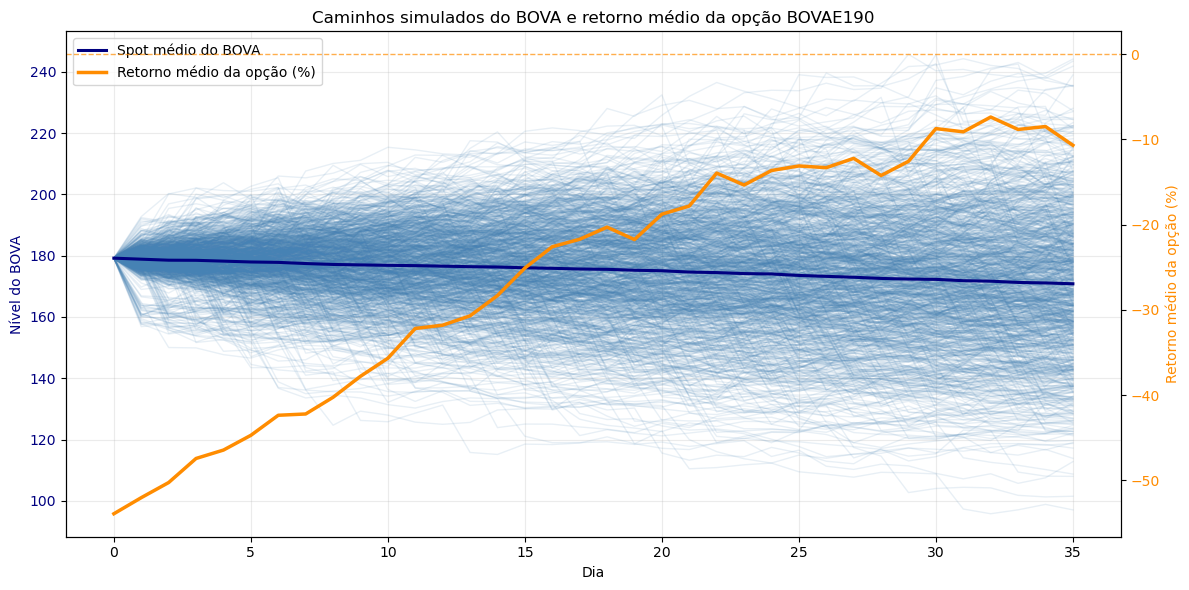

,retorno_medio_pct
dia,
0,-53.938433
1,-52.050522
2,-50.274016
3,-47.447353
4,-46.461667
5,-44.730527
6,-42.376812
7,-42.225900
8,-40.266122


In [13]:
import matplotlib.pyplot as plt


ticker_plot = 'BOVAE190'
capital_plot = 20_000.0
n_caminhos_plot = 1000
seed_plot = 42

afa_plot = encontrar_aba_por_ticker(dataframes_filtrados, ticker_plot)
contexto_plot = montar_contexto_simulacao(dataframes_filtrados, afa_plot, ticker=ticker_plot)
vol_plot = obter_vol_atm(contexto_plot['smile'])

dias_plot = contexto_plot['option'].expiry_days
caminhos_plot = simular_caminhos_indice_bova(
    spot_inicial=contexto_plot['spot_referencia'],
    dias=dias_plot,
    n_caminhos=n_caminhos_plot,
    vol_anual=vol_plot,
    drift_anual=0.0,
    seed=seed_plot,
)

trilhas_plot = []
for caminho_id, caminho in enumerate(caminhos_plot, start=1):
    trilha = precificar_caminho_opcao(
        contexto=contexto_plot,
        caminho_spot=caminho,
        capital_investido=capital_plot,
    ).copy()
    trilha['caminho_id'] = caminho_id
    trilhas_plot.append(trilha)

caminhos_plot_df = pd.concat(trilhas_plot, ignore_index=True)
spots_por_caminho = caminhos_plot_df.pivot(index='dia', columns='caminho_id', values='spot')
retorno_medio_por_dia = (
    caminhos_plot_df.groupby('dia', as_index=True)['retorno_sobre_capital_pct']
    .mean()
    .mul(100.0)
)

fig, ax1 = plt.subplots(figsize=(12, 6))

for coluna in spots_por_caminho.columns:
    ax1.plot(
        spots_por_caminho.index,
        spots_por_caminho[coluna],
        color='steelblue',
        alpha=0.12,
        linewidth=1.0,
    )

ax1.plot(
    spots_por_caminho.index,
    spots_por_caminho.mean(axis=1),
    color='navy',
    linewidth=2.2,
    label='Spot médio do BOVA',
)
ax1.set_xlabel('Dia')
ax1.set_ylabel('Nível do BOVA', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(
    retorno_medio_por_dia.index,
    retorno_medio_por_dia.values,
    color='darkorange',
    linewidth=2.5,
    label='Retorno médio da opção (%)',
)
ax2.axhline(0.0, color='darkorange', linestyle='--', linewidth=1.0, alpha=0.7)
ax2.set_ylabel('Retorno médio da opção (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

linhas_1, labels_1 = ax1.get_legend_handles_labels()
linhas_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(linhas_1 + linhas_2, labels_1 + labels_2, loc='best')

plt.title(f'Caminhos simulados do BOVA e retorno médio da opção {ticker_plot}')
plt.tight_layout()
plt.show()

retorno_medio_por_dia.to_frame(name='retorno_medio_pct').head(10)

## Combinação de call OTM e put OTM

A próxima célula simula conjuntamente uma `call` OTM e uma `put` OTM sobre o BOVA, com o mesmo capital investido em cada perna. O gráfico mostra os caminhos simulados do índice ao fundo e, no eixo secundário, o ganho médio da call, da put e da carteira combinada ao longo do tempo.